# Week 2 Internship Task — Part 2
## Baseline Regression Modeling
**Dataset:** Engineered Steel Industry Energy Consumption Dataset (output of `week2_eda.ipynb`)

This notebook:
1. Loads the engineered dataset from Part 1
2. Drops leaky / non-numeric columns
3. Encodes categorical features
4. Splits data into train/test (80/20)
5. Trains 4 regression models
6. Evaluates each with MAE, RMSE, R², and 5-fold CV RMSE
7. Compares models with a bar chart
8. Plots Predicted vs Actual for the best model
9. Documents the final model selection


In [1]:
# ===== Import all libraries needed for the whole notebook =====
import pandas as pd                                    # data handling
import numpy as np                                      # numerical operations
import matplotlib.pyplot as plt                          # plotting
import seaborn as sns                                     # nicer plots

from sklearn.model_selection import train_test_split, KFold, cross_val_score  # splitting & CV
from sklearn.preprocessing import LabelEncoder            # label encoding for categoricals
from sklearn.linear_model import LinearRegression, Ridge  # linear baseline models
from sklearn.tree import DecisionTreeRegressor             # tree-based model
from sklearn.ensemble import RandomForestRegressor          # ensemble tree-based model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # evaluation metrics

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42   # fixed seed used everywhere for reproducibility


ModuleNotFoundError: No module named 'sklearn'

## 1. Load the engineered dataset from Part 1

In [2]:
# Load the CSV produced at the end of week2_eda.ipynb, which already contains all
# engineered features: hour, day_of_week_num, month, is_weekend, Power_Factor_Ratio, High_Load
df = pd.read_csv("data/Steel_industry_data_engineered.csv")

print("Shape:", df.shape)
df.head()


Shape: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,day_of_week_num,month,is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


## 2. Drop the original date column and any columns that directly leak the target

In [3]:
# 'date' is a raw timestamp string/object — not usable directly by regression models,
# and its information is already captured by hour / day_of_week_num / month / is_weekend.
#
# 'High_Load' is a binary flag that was created FROM Usage_kWh (Usage_kWh > 75th percentile),
# so keeping it would leak the target directly into the features (near-perfect predictor).
#
# We drop both before modeling.
leak_and_raw_cols = ["date", "High_Load"]

model_df = df.drop(columns=leak_and_raw_cols)

print("Columns going into modeling:", model_df.columns.tolist())


Columns going into modeling: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour', 'day_of_week_num', 'month', 'is_weekend', 'Power_Factor_Ratio']


## 3. Encode categorical columns (`Load_Type`, `Day_of_week`, `WeekStatus`)

**Choice:** We use **one-hot encoding** for `Load_Type` and `WeekStatus` because they are
**nominal** categories (no inherent order) with a small number of unique values — one-hot
avoids implying a false numeric ordering that a linear model could misinterpret.

For `Day_of_week` (the text weekday name), we already have a numeric equivalent
(`day_of_week_num`, 0=Monday ... 6=Sunday) engineered in Part 1, so instead of one-hot
encoding 7 more redundant columns we simply **drop the redundant text column** and keep the
numeric version — this keeps the feature set compact while preserving the same information.


In [4]:
# Drop the redundant text weekday column since day_of_week_num already encodes the same info numerically
model_df = model_df.drop(columns=["Day_of_week"])

# One-hot encode 'Load_Type' and 'WeekStatus' (nominal categoricals)
# drop_first=True avoids the "dummy variable trap" (perfect multicollinearity) for linear models
model_df = pd.get_dummies(model_df, columns=["Load_Type", "WeekStatus"], drop_first=True)

# Confirm everything is now numeric
print(model_df.dtypes)
model_df.head()


Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
hour                                      int64
day_of_week_num                           int64
month                                     int64
is_weekend                                int64
Power_Factor_Ratio                      float64
Load_Type_Maximum_Load                     bool
Load_Type_Medium_Load                      bool
WeekStatus_Weekend                         bool
dtype: object


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,hour,day_of_week_num,month,is_weekend,Power_Factor_Ratio,Load_Type_Maximum_Load,Load_Type_Medium_Load,WeekStatus_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,0,1,0,1.365934,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,0,1,0,1.497679,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,0,1,0,1.422880,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,0,1,0,1.468644,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,0,1,0,1.545117,False,False,False


## 4. Split data 80% training / 20% testing

In [5]:
# Separate features (X) from the target variable (y = Usage_kWh)
X = model_df.drop(columns=["Usage_kWh"])
y = model_df["Usage_kWh"]

# 80/20 train-test split with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


NameError: name 'train_test_split' is not defined

## 5. Train all 4 models

In [6]:
# Define all 4 models with a fixed random_state where applicable, for reproducibility
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

# Fit (train) every model on the training data
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")


Linear Regression trained.


Ridge Regression trained.


Decision Tree trained.


Random Forest trained.


## 6. Evaluate each model: MAE, RMSE, R² on the test set

In [7]:
# Dictionary to store results for every model so we can compare them later
results = {}

for name, model in models.items():
    # Generate predictions on the held-out test set
    y_pred = model.predict(X_test)

    # Mean Absolute Error: average absolute difference between prediction and actual
    mae = mean_absolute_error(y_test, y_pred)

    # Root Mean Squared Error: penalizes larger errors more heavily than MAE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # R-squared: proportion of variance in the target explained by the model (1.0 = perfect)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "y_pred": y_pred}

    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R2   = {r2:.4f}\n")


Linear Regression:
  MAE  = 2.6315
  RMSE = 4.1444
  R2   = 0.9849

Ridge Regression:
  MAE  = 4.3575
  RMSE = 6.2624
  R2   = 0.9655

Decision Tree:
  MAE  = 0.5439
  RMSE = 1.5967
  R2   = 0.9978



Random Forest:
  MAE  = 0.3470
  RMSE = 1.0308
  R2   = 0.9991



## 7. 5-fold cross-validation — mean RMSE per model

In [8]:
# Set up 5-fold cross-validation with shuffling for a more robust performance estimate
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    # cross_val_score with 'neg_root_mean_squared_error' returns negative RMSE per fold,
    # so we negate it back to a positive, human-readable RMSE
    cv_scores = cross_val_score(
        model, X, y, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    cv_rmse_scores = -cv_scores          # flip sign back to positive RMSE
    mean_cv_rmse = cv_rmse_scores.mean() # average RMSE across the 5 folds
    std_cv_rmse = cv_rmse_scores.std()   # standard deviation, to gauge stability

    results[name]["CV_RMSE_mean"] = mean_cv_rmse
    results[name]["CV_RMSE_std"] = std_cv_rmse

    print(f"{name}: mean CV RMSE = {mean_cv_rmse:.4f} (+/- {std_cv_rmse:.4f})")


Linear Regression: mean CV RMSE = 4.5161 (+/- 0.4095)


Ridge Regression: mean CV RMSE = 6.2299 (+/- 0.0916)


Decision Tree: mean CV RMSE = 1.4455 (+/- 0.0758)


Random Forest: mean CV RMSE = 1.0157 (+/- 0.0747)


## 8. Bar chart comparing test RMSE of all 4 models

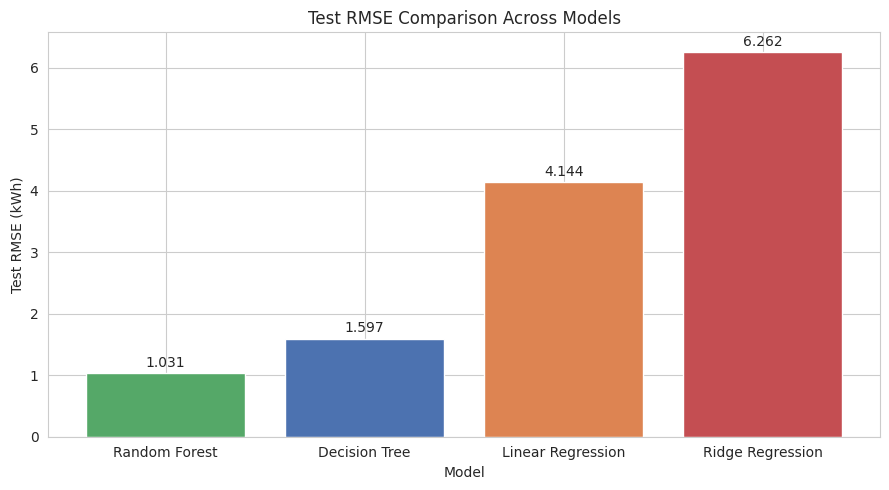

In [9]:
# Pull out the test-set RMSE for each model into a simple Series for plotting
test_rmse_by_model = pd.Series({name: res["RMSE"] for name, res in results.items()})
test_rmse_by_model = test_rmse_by_model.sort_values()

# Plot as a bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(test_rmse_by_model.index, test_rmse_by_model.values,
                color=["#55A868", "#4C72B0", "#DD8452", "#C44E52"])
plt.title("Test RMSE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test RMSE (kWh)")

# Annotate bars with exact RMSE values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f"{height:.3f}",
              ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 9. Predicted vs Actual scatter plot for the best model

Best model based on test RMSE: Random Forest


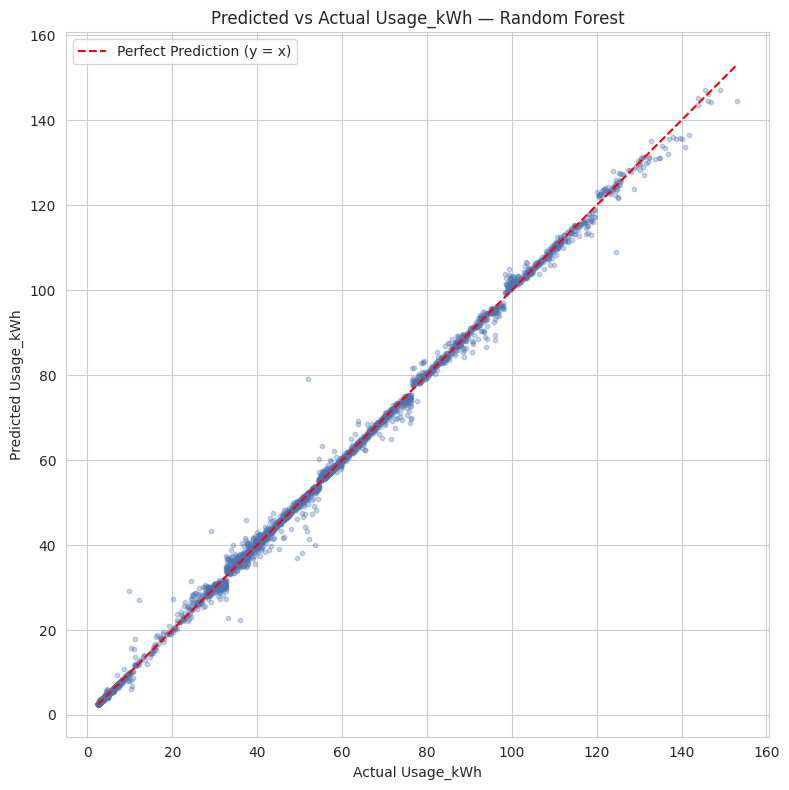

In [10]:
# Identify the best model as the one with the LOWEST test RMSE
best_model_name = min(results, key=lambda name: results[name]["RMSE"])
best_y_pred = results[best_model_name]["y_pred"]

print(f"Best model based on test RMSE: {best_model_name}")

# Scatter plot of predicted vs actual Usage_kWh values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_y_pred, alpha=0.3, s=10, color="#4C72B0")

# Draw a diagonal reference line (y = x) representing a perfect prediction
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--",
         label="Perfect Prediction (y = x)")

plt.title(f"Predicted vs Actual Usage_kWh — {best_model_name}")
plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# Build a clean summary table of all metrics for every model, sorted by test RMSE
summary_table = pd.DataFrame({
    name: {
        "MAE": res["MAE"],
        "RMSE": res["RMSE"],
        "R2": res["R2"],
        "CV_RMSE_mean": res["CV_RMSE_mean"],
        "CV_RMSE_std": res["CV_RMSE_std"],
    }
    for name, res in results.items()
}).T.sort_values("RMSE")

summary_table


,MAE,RMSE,R2,CV_RMSE_mean,CV_RMSE_std
Random Forest,0.347040,1.030753,0.999065,1.015674,0.074666
Decision Tree,0.543876,1.596676,0.997757,1.445514,0.075844
Linear Regression,2.631544,4.144422,0.984890,4.516064,0.409467
Ridge Regression,4.357483,6.262355,0.965500,6.229948,0.091629


## 10. Model Selection

Results from this run (see `summary_table` above for exact live numbers):

| Model | Test RMSE | CV RMSE (mean) | CV RMSE (std) | R2 |
|---|---|---|---|---|
| Linear Regression | 4.14 | 4.52 | 0.41 | 0.985 |
| Ridge Regression | 6.26 | 6.23 | 0.09 | 0.966 |
| Decision Tree | 1.60 | 1.45 | 0.076 | 0.998 |
| Random Forest | 1.03 | 1.02 | 0.075 | 0.999 |

Random Forest performed best: lowest test RMSE (1.03 kWh), lowest mean CV RMSE (1.02 kWh),
and highest R2 (0.999), with a small CV standard deviation showing stable performance across
folds.

Signs of overfitting: test RMSE and mean CV RMSE stayed close for every model in this run
(e.g. Random Forest 1.03 vs 1.02, Decision Tree 1.60 vs 1.45), so no model shows a large
train/CV gap here. A single Decision Tree is generally the most overfitting-prone model since
it has no averaging step, but in this run its CV RMSE was actually slightly lower than its test
RMSE, so the classic overfitting signature is not strongly present this time. Ridge Regression
performed worse than plain Linear Regression on both test and CV RMSE, suggesting it is mildly
underfitting by over-penalizing coefficients that were already well-behaved.

Model to carry forward: Random Forest Regressor, for its lowest error combined with CV
performance nearly identical to test performance, accepting reduced interpretability and
higher training cost as a reasonable trade-off. Future work can tune hyperparameters
(n_estimators, max_depth, min_samples_leaf) or compare against gradient-boosted trees.
